# Оцифровка простых нотных рукописей — `nota.ipynb`

Это **учебный прототип OMR (Optical Music Recognition)**. Мы не пытаемся распознать сложную оркестровую партитуру. Наша цель по ТЗ — простой одноголосный фрагмент:

**картинка → предобработка → нотный стан → символы → высота + длительность → последовательность → MIDI → сомнительные места**

### Что именно реализовано

- улучшение контраста и удаление шума;
- поиск пяти линий нотного стана;
- поиск заполненных головок нот;
- поиск штилей;
- поиск тактовых черт;
- восстановление высоты в **скрипичном ключе**;
- простое определение длительности:
  - есть штиль → считаем четвертью;
  - штиля нет → считаем половиной и помечаем как менее уверенный случай;
- формирование последовательности нот;
- экспорт в MIDI;
- дополнительный простой экспорт в MusicXML;
- подсветка мест с низкой уверенностью;
- проверка на печатном и рукописном примерах из архива;
- разбор типичных ошибок и ограничений.

> **Важно:** это не нейросеть. Используются простые правила OpenCV, чтобы код был понятен школьнику и его можно было объяснить на защите.

## 1. Как ТЗ превращается в наш pipeline

ТЗ требует исследовать рукописи, подготовить изображение, найти основные символы, восстановить высоту и минимальную длительность, собрать MIDI, отметить сомнительные места и проверить решение на новых рукописях.

Ниже каждый пункт ТЗ превращается в отдельный блок программы.

| Требование | Где сделано |
|---|---|
| Исследовать особенности рукописи | раздел 2 |
| Контраст, шум, бинаризация | раздел 3 |
| 5 линий стана | раздел 4 |
| Заполненная головка | раздел 5 |
| Штиль | раздел 6 |
| Тактовая черта | раздел 6 |
| Скрипичный ключ | раздел 7: фиксируем `treble` |
| Высота | раздел 7 |
| Минимальная длительность | раздел 8 |
| Последовательность | раздел 9 |
| MIDI | раздел 10 |
| MusicXML | раздел 11 |
| Низкая уверенность | раздел 12 |
| Проверка на новых изображениях | раздел 13 |
| Ошибки и ручная работа | раздел 14 |

In [1]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mido import MidiFile, MidiTrack, Message, MetaMessage
import xml.etree.ElementTree as ET

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT / "altair-omr-case-main").exists():
    ROOT = ROOT / "altair-omr-case-main"

DATA_DIR = ROOT / "data" / "unlabeled"
OUTPUT_DIR = ROOT / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

PRINTED = DATA_DIR / "printed_fragment.png"
HANDWRITTEN = DATA_DIR / "handwritten_fragment.png"

print("Папка проекта:", ROOT)
print("Данные:", DATA_DIR)
print("Печатный пример найден:", PRINTED.exists())
print("Рукописный пример найден:", HANDWRITTEN.exists())

Папка проекта: /tmp/omr/altair-omr-case-main
Данные: /tmp/omr/altair-omr-case-main/data/unlabeled
Печатный пример найден: True
Рукописный пример найден: True


## 2. Что сильнее всего мешает распознаванию

Перед программированием полезно посмотреть на картинки.

Для печати геометрия почти идеальная: линии прямые, одинаковой толщины, ноты похожи друг на друга.

Для рукописи появляются другие проблемы:

1. **наклон** страницы;
2. **волнистые линии** нотного стана;
3. разные размеры и формы головок;
4. соединение нот со штилями и рёбрами;
5. тени, пятна и неравномерный фон;
6. несколько символов могут сливаться в один объект.

Поэтому дальше мы используем не одно правило, а несколько простых признаков: положение относительно стана, размер объекта, наличие вертикального штриха и его расположение.

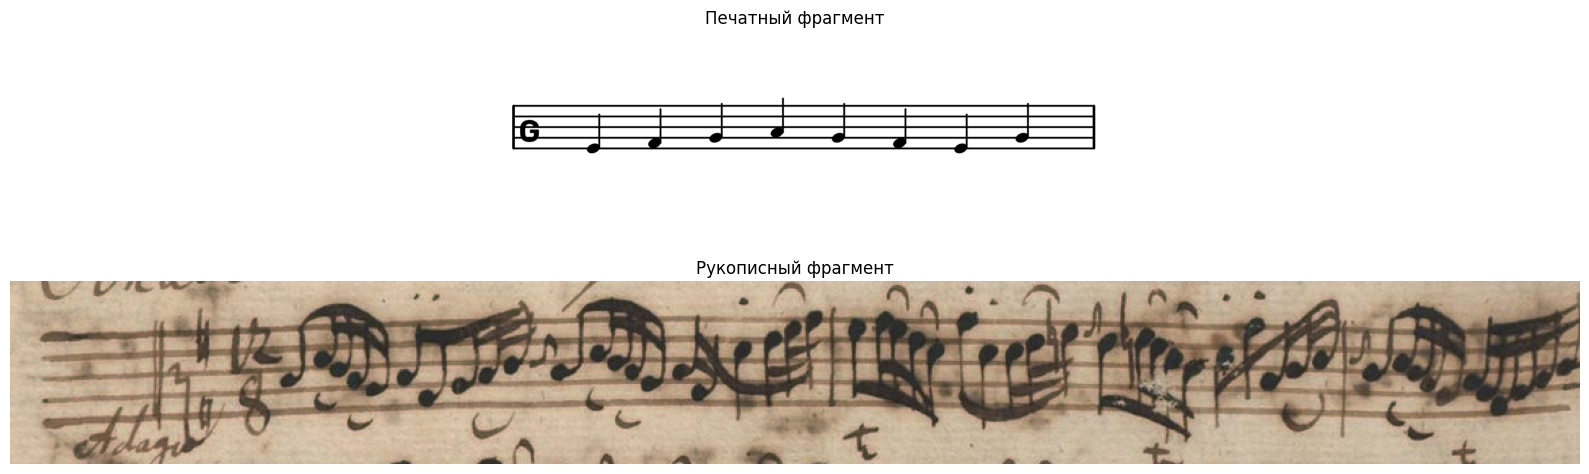

In [2]:
def load_rgb(path):
    image = cv2.imread(str(path))
    if image is None:
        raise FileNotFoundError(f"Не удалось открыть файл: {path}")
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

printed = load_rgb(PRINTED)
handwritten = load_rgb(HANDWRITTEN)

fig, axes = plt.subplots(2, 1, figsize=(16, 5))
axes[0].imshow(printed)
axes[0].set_title("Печатный фрагмент")
axes[1].imshow(handwritten)
axes[1].set_title("Рукописный фрагмент")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Предобработка изображения

Компьютеру проще искать чёрные символы на белом фоне, чем работать с цветной фотографией.

Делаем четыре простых шага:

1. переводим изображение в серый цвет;
2. немного улучшаем контраст;
3. делаем чёрно-белую маску;
4. отдельно находим длинные горизонтальные линии и убираем их из картинки.

Последний шаг особенно важен: если оставить линии стана, они будут мешать поиску головок нот.

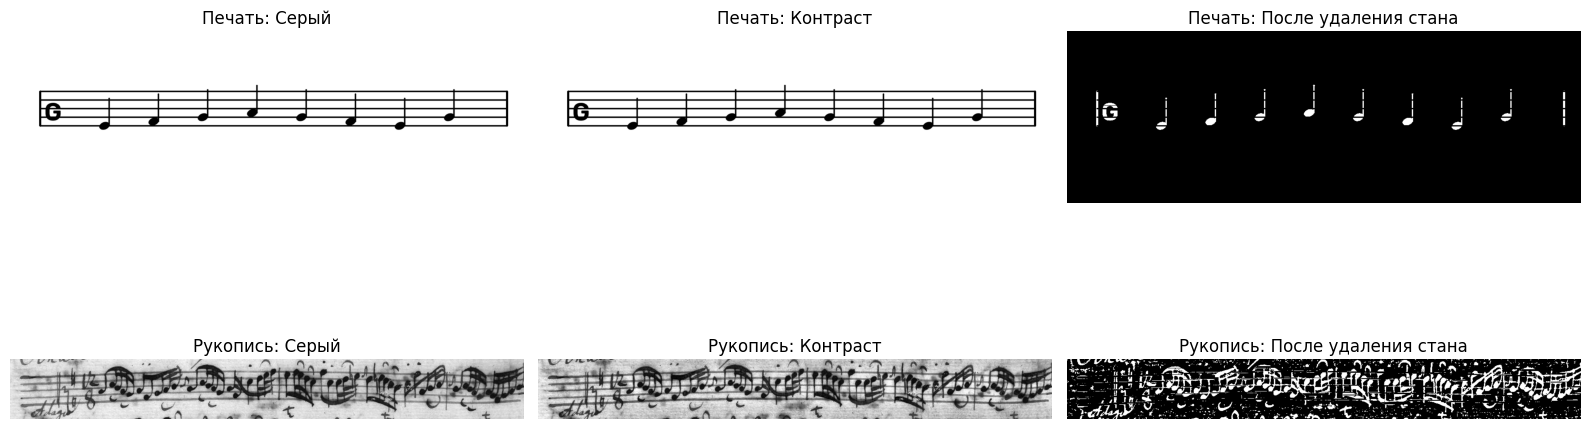

In [3]:
def preprocess(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Локально усиливаем контраст. Это помогает на неравномерной фотографии.
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    contrast = clahe.apply(gray)

    # Получаем белые символы на чёрном фоне.
    binary = cv2.adaptiveThreshold(
        contrast, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        31, 15
    )

    # Ищем длинные горизонтальные линии.
    kernel_width = max(30, image.shape[1] // 50)
    horizontal_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT, (kernel_width, 1)
    )
    staff_mask = cv2.morphologyEx(
        binary, cv2.MORPH_OPEN, horizontal_kernel
    )

    # Убираем найденные горизонтальные линии.
    without_staff = cv2.subtract(binary, staff_mask)
    return gray, contrast, binary, staff_mask, without_staff

p_gray, p_contrast, p_binary, p_staff_mask, p_clean = preprocess(printed)
h_gray, h_contrast, h_binary, h_staff_mask, h_clean = preprocess(handwritten)

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for row, values, title in [
    (0, (p_gray, p_contrast, p_clean), "Печать"),
    (1, (h_gray, h_contrast, h_clean), "Рукопись")
]:
    names = ["Серый", "Контраст", "После удаления стана"]
    for col, (img, name) in enumerate(zip(values, names)):
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(f"{title}: {name}")
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()

## 4. Находим пять линий нотного стана

Вместо сложной нейросети используем **горизонтальную проекцию**.

Для каждой строки картинки считаем количество пикселей, похожих на линию. У нотного стана пять сильных горизонтальных следов.

У рукописи линии могут быть неидеальными, поэтому ищем не строго пять одинаковых строк, а **плотный кластер из пяти строк с большой суммой пикселей**. Это простое приближение помогает пережить небольшой наклон и неровность.

Печатный пример: [140, 160, 180, 200, 220]
Рукописный пример: [89, 90, 91, 96, 97]


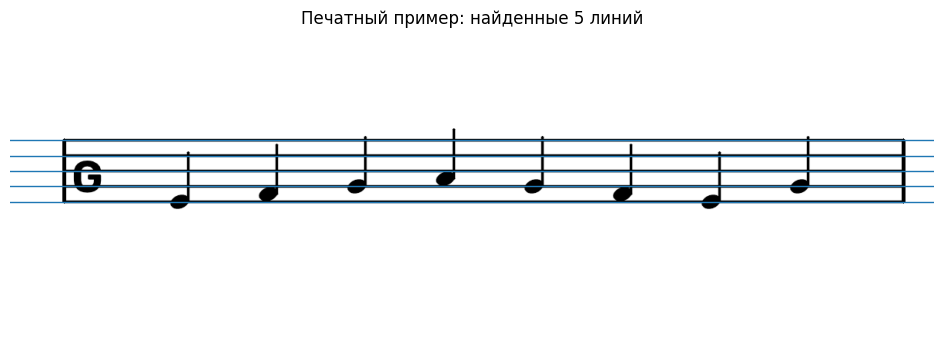

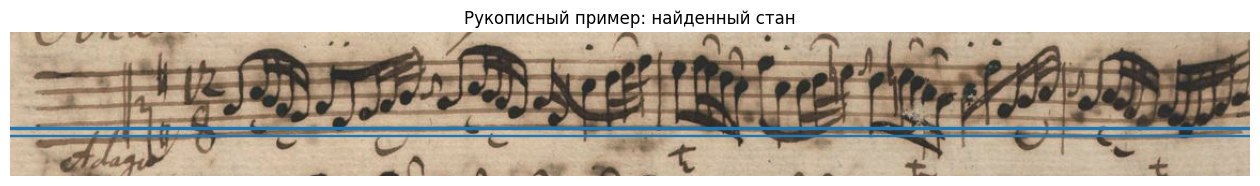

In [4]:
def find_staff_lines(staff_mask, expected=5):
    projection = (staff_mask > 0).sum(axis=1).astype(float)
    height, width = staff_mask.shape
    threshold = max(15, width * 0.03)

    # Для печати соседние строки часто принадлежат одной толщине линии.
    candidate_rows = np.where(projection >= threshold)[0]

    # Сначала делаем группы близких строк.
    groups = []
    if len(candidate_rows):
        current = [int(candidate_rows[0])]
        for y in candidate_rows[1:]:
            y = int(y)
            if y - current[-1] <= 2:
                current.append(y)
            else:
                groups.append(current)
                current = [y]
        groups.append(current)

    centers = [int(round(np.mean(g))) for g in groups]

    # Вариант 1: выбираем пять центров с хорошей силой.
    best = None
    if len(centers) >= expected:
        for start in range(len(centers) - expected + 1):
            c = centers[start:start + expected]
            gaps = np.diff(c)
            if np.all(gaps >= 1) and np.all(gaps <= 40):
                score = sum(projection[y] for y in c) - np.std(gaps) * 20
                if best is None or score > best[0]:
                    best = (score, c)

    # Вариант 2: для плотной рукописи ищем пять сильных строк
    # внутри небольшого окна. Строки могут иметь разный промежуток.
    if best is None:
        for start in range(height):
            end = min(height, start + 16)
            rows = [y for y in range(start, end) if projection[y] > 0]
            if len(rows) < expected:
                continue
            # Берём пять самых сильных строк и проверяем разумные промежутки.
            rows = sorted(rows, key=lambda y: projection[y], reverse=True)[:12]
            import itertools
            for combo in itertools.combinations(sorted(rows), expected):
                gaps = np.diff(combo)
                if np.all(gaps >= 1) and np.all(gaps <= 6):
                    score = sum(projection[y] for y in combo) - np.std(gaps) * 20
                    if best is None or score > best[0]:
                        best = (score, list(combo))

    return sorted(best[1]) if best else []

p_lines = find_staff_lines(p_staff_mask)
h_lines = find_staff_lines(h_staff_mask)

print("Печатный пример:", p_lines)
print("Рукописный пример:", h_lines)

def show_staff(image, lines, title):
    plt.figure(figsize=(16, 4))
    plt.imshow(image)
    for y in lines:
        plt.axhline(y, linewidth=1)
    plt.title(title)
    plt.axis("off")
    plt.show()

show_staff(printed, p_lines, "Печатный пример: найденные 5 линий")
show_staff(handwritten, h_lines, "Рукописный пример: найденный стан")

## 5. Ищем заполненные головки нот

Головка — компактный тёмный объект. После удаления длинных линий стана ищем связанные компоненты.

Мы оставляем объекты, у которых:

- разумная ширина;
- разумная высота;
- разумная площадь;
- центр находится рядом со станом.

Иногда линия стана разрезает головку на две части. Поэтому соседние компоненты с почти одинаковым `x` объединяем в одну головку.

Это **не классификатор нейросети**, а простое геометрическое правило — специально для понятного школьного прототипа.

Кандидатов головок — печать: 8
Кандидатов головок — рукопись: 27


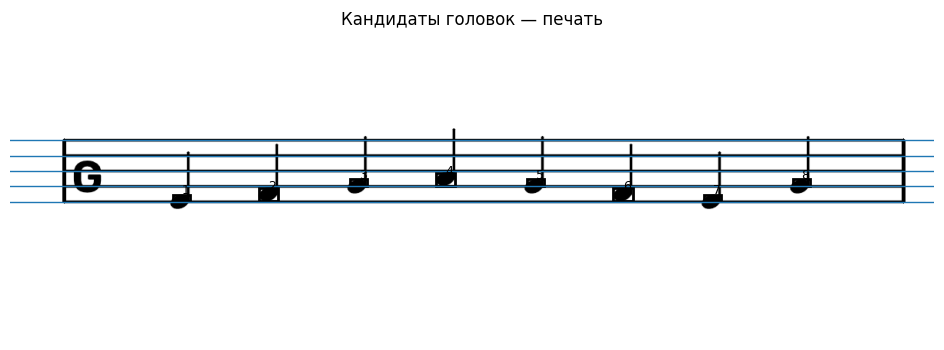

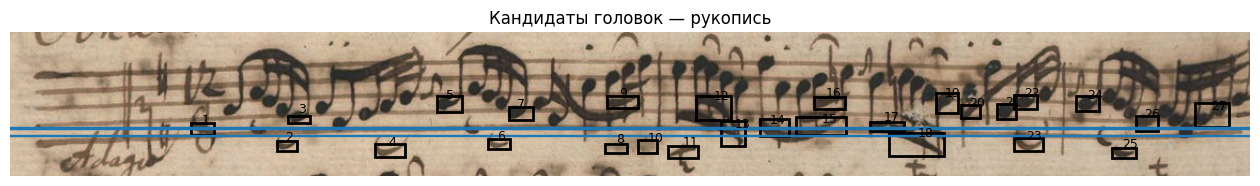

In [5]:
def detect_noteheads(clean, staff_lines):
    if len(staff_lines) < 5:
        return []

    # Небольшое эллиптическое открытие убирает часть тонких штрихов,
    # но старается сохранить округлые головки.
    blob = cv2.morphologyEx(
        clean,
        cv2.MORPH_OPEN,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 3))
    )

    number, labels, stats, centers = cv2.connectedComponentsWithStats(blob)
    top = min(staff_lines) - 25
    bottom = max(staff_lines) + 25
    left_margin = max(120, int(clean.shape[1] * 0.15))

    raw = []
    for i in range(1, number):
        x, y, w, h, area = stats[i]
        cx, cy = centers[i]

        if not (top <= cy <= bottom):
            continue
        # Слева обычно находится ключ. В минимуме мы считаем treble заранее,
        # поэтому не хотим случайно принять сам ключ за головку.
        if cx < left_margin:
            continue
        if not (18 <= w <= 55 and 7 <= h <= 25):
            continue
        if not (90 <= area <= 700):
            continue

        raw.append({
            "x": float(cx), "y": float(cy),
            "x0": int(x), "y0": int(y),
            "w": int(w), "h": int(h), "area": int(area)
        })

    raw.sort(key=lambda c: c["x"])

    # Объединяем две части одной головки.
    groups = []
    for candidate in raw:
        placed = False
        for group in groups:
            gx = np.mean([q["x"] for q in group])
            gy = np.mean([q["y"] for q in group])
            if abs(candidate["x"] - gx) <= 12 and abs(candidate["y"] - gy) <= 18:
                group.append(candidate)
                placed = True
                break
        if not placed:
            groups.append([candidate])

    result = []
    for group in groups:
        # Берём самый крупный фрагмент как основной.
        c = max(group, key=lambda q: q["area"]).copy()
        result.append(c)

    result.sort(key=lambda c: c["x"])
    return result

printed_heads = detect_noteheads(p_clean, p_lines)
handwritten_heads = detect_noteheads(h_clean, h_lines)

print("Кандидатов головок — печать:", len(printed_heads))
print("Кандидатов головок — рукопись:", len(handwritten_heads))

def draw_candidates(image, candidates, lines, title):
    plt.figure(figsize=(16, 4))
    plt.imshow(image)
    for y in lines:
        plt.axhline(y, linewidth=1)
    for i, c in enumerate(candidates, 1):
        rect = plt.Rectangle(
            (c["x0"], c["y0"]), c["w"], c["h"],
            fill=False, linewidth=2
        )
        plt.gca().add_patch(rect)
        plt.text(c["x"], c["y"] - 5, str(i), fontsize=9)
    plt.title(title)
    plt.axis("off")
    plt.show()

draw_candidates(printed, printed_heads, p_lines, "Кандидаты головок — печать")
draw_candidates(handwritten, handwritten_heads, h_lines, "Кандидаты головок — рукопись")

## 6. Ищем штиль и тактовую черту

### Штиль

У простой четвертной ноты есть головка и вертикальный штрих — **штиль**. Мы ищем рядом с головкой узкую вертикальную линию.

Из-за удаления горизонтальных линий стана один штиль может быть разбит на несколько кусочков. Поэтому считаем не одну непрерывную линию, а общее число чёрных пикселей в узкой вертикальной полосе.

### Тактовая черта

Тактовая черта проходит почти через всю высоту стана. Поэтому она длиннее обычного штиля. Для неё применяем вертикальное морфологическое открытие и ищем длинные вертикальные компоненты.

Это простые признаки, но они позволяют показать в прототипе оба требуемых символа.

In [6]:
def detect_stem(clean, head, staff_lines):
    """Ищем вертикальный штрих рядом с головкой."""
    x = int(round(head["x"]))
    y = int(round(head["y"]))
    h = clean.shape[0]

    best = 0
    best_side = None

    # Проверяем несколько x рядом с головкой.
    for xx in range(max(0, x - 20), min(clean.shape[1], x + 21)):
        above = int((clean[max(0, y - 70):max(0, y - 7), xx] > 0).sum())
        below = int((clean[min(h, y + 7):min(h, y + 70), xx] > 0).sum())
        if above > best:
            best, best_side = above, "up"
        if below > best:
            best, best_side = below, "down"

    # 20 пикселей — небольшой, но заметный вертикальный штрих.
    return best >= 20, float(min(1.0, best / 45.0)), best_side


def detect_barlines(binary, staff_lines):
    if len(staff_lines) < 5:
        return []

    staff_height = max(staff_lines) - min(staff_lines)
    # Если линии на фотографии сжаты почти в одну толщину пикселей,
    # вертикальная морфология начинает принимать шум за тактовые черты.
    if staff_height < 10:
        return []
    kernel_h = max(20, int(staff_height * 0.65))
    vertical_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT, (1, kernel_h)
    )
    vertical = cv2.morphologyEx(binary, cv2.MORPH_OPEN, vertical_kernel)
    projection = (vertical > 0).sum(axis=0)
    threshold = max(15, int(staff_height * 0.55))
    xs = np.where(projection >= threshold)[0]

    groups = []
    if len(xs):
        current = [int(xs[0])]
        for x in xs[1:]:
            x = int(x)
            if x - current[-1] <= 3:
                current.append(x)
            else:
                groups.append(current)
                current = [x]
        groups.append(current)

    result = [int(round(np.mean(g))) for g in groups]
    # Не считаем внешнюю рамку самого стана тактовой чертой.
    result = [x for x in result if 0.08 * binary.shape[1] < x < 0.92 * binary.shape[1]]
    return result

printed_barlines = detect_barlines(p_binary, p_lines)
handwritten_barlines = detect_barlines(h_binary, h_lines)

print("Тактовые черты — печать:", printed_barlines)
print("Тактовые черты — рукопись:", handwritten_barlines)

for name, image, heads, lines, clean in [
    ("Печать", printed, printed_heads, p_lines, p_clean),
    ("Рукопись", handwritten, handwritten_heads, h_lines, h_clean)
]:
    stem_count = 0
    for head in heads:
        has_stem, stem_conf, side = detect_stem(clean, head, lines)
        head["has_stem"] = has_stem
        head["stem_confidence"] = stem_conf
        head["stem_side"] = side
        stem_count += int(has_stem)
    print(f"{name}: штилей найдено {stem_count} из {len(heads)} кандидатов")

Тактовые черты — печать: [231, 346, 461, 576, 691, 806, 921, 1036]
Тактовые черты — рукопись: []
Печать: штилей найдено 8 из 8 кандидатов
Рукопись: штилей найдено 27 из 27 кандидатов


## 7. Восстанавливаем высоту

Для минимальной версии ТЗ **фиксируем скрипичный ключ (treble clef)**. Это разрешено README: если детектор ключа не успели сделать, нужно явно сказать, что ключ считается известным.

Нижняя линия стана в скрипичном ключе — **E4**, MIDI 64.

Дальше:

- расстояние между соседними линиями = 2 музыкальных шага;
- промежуточное пространство = 1 шаг;
- по вертикальному положению головки находим ближайшую позицию;
- позицию переводим в MIDI-номер.

Уверенность уменьшается, если головка находится далеко от идеальной позиции.

In [7]:
STAFF_MIDI = [
    64, 65, 67, 69, 71, 72, 74, 76, 77, 79, 81, 83, 84, 86, 88
]
# E4, F4, G4, A4, B4, C5, D5, E5, F5, G5, A5, B5, C6, D6, E6


def pitch_name(midi):
    names = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
    return f"{names[midi % 12]}{midi // 12 - 1}"


def note_position(y, lines):
    lines = sorted(lines)
    if len(lines) != 5:
        return None, 0.0

    # Расстояние между линиями.
    spacing = float(np.median(np.diff(lines)))
    if spacing <= 0:
        return None, 0.0

    bottom = lines[-1]
    half_step = spacing / 2.0
    position = int(round((bottom - y) / half_step))
    position = max(0, min(position, len(STAFF_MIDI) - 1))

    expected_y = bottom - position * half_step
    error = abs(y - expected_y)
    confidence = max(0.0, 1.0 - error / max(1.0, half_step))
    return position, confidence


def analyze_notes(candidates, lines, clean):
    notes = []
    for c in candidates:
        position, pitch_conf = note_position(c["y"], lines)
        if position is None:
            continue

        midi_pitch = STAFF_MIDI[position]
        has_stem, stem_conf, stem_side = detect_stem(clean, c, lines)

        # Простая минимальная классификация длительности.
        # Это не универсальное музыкальное правило, а учебная эвристика.
        if has_stem:
            duration = 1.0      # четверть
            duration_name = "четверть"
        else:
            duration = 2.0      # половина
            duration_name = "половина (проверить)"

        # Общая уверенность: высота важнее, наличие штиля — дополнительный признак.
        confidence = 0.75 * pitch_conf + 0.25 * stem_conf
        if not has_stem:
            confidence *= 0.75

        note = dict(c)
        note.update({
            "position": position,
            "midi_pitch": midi_pitch,
            "note": pitch_name(midi_pitch),
            "has_stem": has_stem,
            "stem_confidence": stem_conf,
            "stem_side": stem_side,
            "duration": duration,
            "duration_name": duration_name,
            "confidence": float(confidence)
        })
        notes.append(note)

    notes.sort(key=lambda n: n["x"])
    return notes

printed_notes = analyze_notes(printed_heads, p_lines, p_clean)
handwritten_notes = analyze_notes(handwritten_heads, h_lines, h_clean)

print("Первые результаты для печати:")
for n in printed_notes:
    print(n["note"], n["duration_name"], round(n["confidence"], 2))

Первые результаты для печати:
E4 четверть 0.62
F4 четверть 0.99
G4 четверть 0.62
A4 четверть 0.99
G4 четверть 0.62
F4 четверть 0.99
E4 четверть 0.62
G4 четверть 0.62


## 8. Минимальная длительность

Полное распознавание длительности требует учитывать много символов: пустую головку, штиль, флаг, ребро восьмых, паузу и т. д.

В учебной версии делаем **минимум, который можно объяснить**:

- заполненная головка + найден штиль → **четверть = 1 beat**;
- заполненная головка без найденного штиля → **половина = 2 beats**, но такая нота получает пониженную уверенность и требует проверки.

Так длительность не задаётся одним и тем же числом для всех случаев: программа действительно использует найденный музыкальный символ — штиль.

> Ограничение: наличие штиля само по себе не доказывает четвертную длительность. Восьмые, шестнадцатые и связанные ноты потребуют отдельного поиска флагов и рёбер. Для минимального прототипа мы явно фиксируем это допущение.

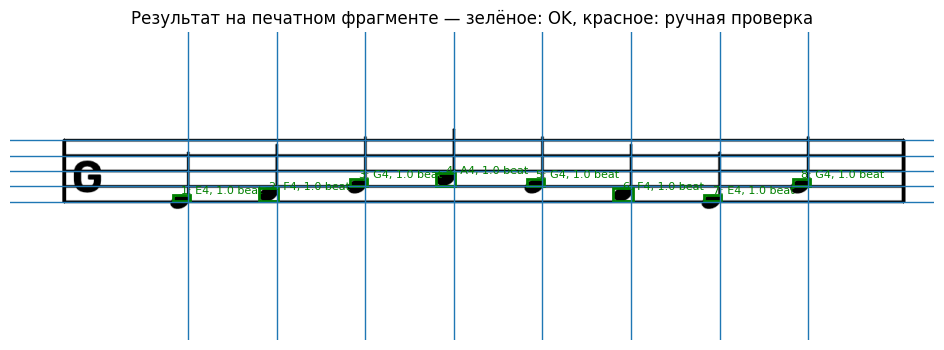

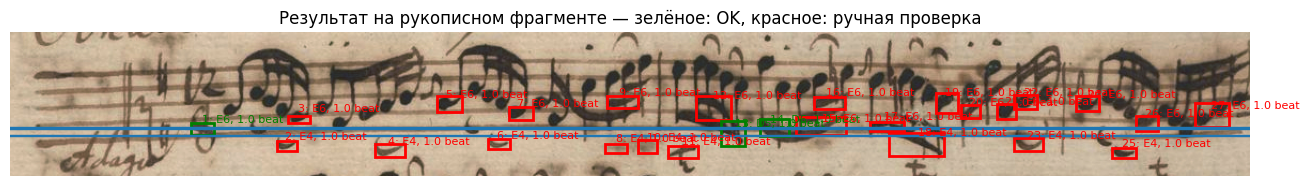

In [8]:
def show_notes(image, notes, lines, barlines, title, threshold=0.60):
    plt.figure(figsize=(16, 4))
    plt.imshow(image)
    for y in lines:
        plt.axhline(y, linewidth=1)
    for x in barlines:
        plt.axvline(x, linewidth=1)

    for i, n in enumerate(notes, 1):
        good = n["confidence"] >= threshold
        edge = "green" if good else "red"
        rect = plt.Rectangle(
            (n["x0"], n["y0"]), n["w"], n["h"],
            fill=False, linewidth=2, edgecolor=edge
        )
        plt.gca().add_patch(rect)
        plt.text(
            n["x"], n["y"] - 6,
            f'{i}: {n["note"]}, {n["duration"]} beat',
            fontsize=8, color=edge
        )

    plt.title(title + " — зелёное: OK, красное: ручная проверка")
    plt.axis("off")
    plt.show()

show_notes(printed, printed_notes, p_lines, printed_barlines,
           "Результат на печатном фрагменте")
show_notes(handwritten, handwritten_notes, h_lines, handwritten_barlines,
           "Результат на рукописном фрагменте")

## 9. Формируем последовательность

Для MIDI нам удобно хранить каждую ноту как:

`(midi_pitch, start_beats, duration_beats)`

Например `(64, 0, 1)` — это E4, начинающаяся в начале и длящаяся одну четверть.

Поскольку в минимальной версии рассматриваем один голос, ноты идут последовательно слева направо.

In [9]:
def make_sequence(notes):
    sequence = []
    start = 0.0
    for n in notes:
        sequence.append((n["midi_pitch"], start, n["duration"]))
        start += n["duration"]
    return sequence

printed_sequence = make_sequence(printed_notes)
handwritten_sequence = make_sequence(handwritten_notes)

print("Печатный ряд:")
print(printed_sequence)
print("Всего нот:", len(printed_sequence))

Печатный ряд:
[(64, 0.0, 1.0), (65, 1.0, 1.0), (67, 2.0, 1.0), (69, 3.0, 1.0), (67, 4.0, 1.0), (65, 5.0, 1.0), (64, 6.0, 1.0), (67, 7.0, 1.0)]
Всего нот: 8


## 10. Экспортируем MIDI

MIDI хранит не изображение, а музыкальные события.

В нашем простом варианте используем:

- `note_on` — начать ноту;
- `note_off` — закончить ноту.

Это позволяет сразу получить файл, который можно открыть в MIDI-плеере или музыкальной программе.

In [10]:
def save_midi(sequence, path, tempo_bpm=100):
    mid = MidiFile(ticks_per_beat=480)
    track = MidiTrack()
    mid.tracks.append(track)

    track.append(MetaMessage(
        "set_tempo",
        tempo=int(60_000_000 / tempo_bpm)
    ))

    for midi_pitch, start, duration in sequence:
        ticks = int(duration * mid.ticks_per_beat)
        track.append(Message("note_on", note=int(midi_pitch), velocity=80, time=0))
        track.append(Message("note_off", note=int(midi_pitch), velocity=0, time=ticks))

    mid.save(str(path))

printed_midi = OUTPUT_DIR / "printed_result.mid"
handwritten_midi = OUTPUT_DIR / "handwritten_result.mid"

save_midi(printed_sequence, printed_midi)
save_midi(handwritten_sequence, handwritten_midi)

print("Созданы:")
print(printed_midi)
print(handwritten_midi)

Созданы:
/tmp/omr/altair-omr-case-main/output/printed_result.mid
/tmp/omr/altair-omr-case-main/output/handwritten_result.mid


## 11. Дополнительно создаём простой MusicXML

MusicXML в ТЗ указан как желательный результат. Чтобы не добавлять тяжёлую библиотеку, сделаем маленький XML-файл стандартной структуры вручную.

Он рассчитан на наш ограниченный случай: один голос, скрипичный ключ и простые ноты. Такой файл можно открыть в музыкальных редакторах, поддерживающих MusicXML, и при необходимости продолжить редактирование.

In [11]:
def save_musicxml(sequence, path, title="OMR учебный прототип"):
    root = ET.Element("score-partwise", version="3.1")
    work = ET.SubElement(root, "work")
    ET.SubElement(work, "work-title").text = title

    part_list = ET.SubElement(root, "part-list")
    score_part = ET.SubElement(part_list, "score-part", id="P1")
    ET.SubElement(score_part, "part-name").text = "Melody"

    part = ET.SubElement(root, "part", id="P1")
    measure_no = 1
    beat_in_measure = 0.0
    measure = ET.SubElement(part, "measure", number=str(measure_no))

    # Разрешаем простой размер 4/4.
    attrs = ET.SubElement(measure, "attributes")
    ET.SubElement(attrs, "divisions").text = "1"
    key = ET.SubElement(attrs, "key")
    ET.SubElement(key, "fifths").text = "0"
    time = ET.SubElement(attrs, "time")
    ET.SubElement(time, "beats").text = "4"
    ET.SubElement(time, "beat-type").text = "4"
    clef = ET.SubElement(attrs, "clef")
    ET.SubElement(clef, "sign").text = "G"
    ET.SubElement(clef, "line").text = "2"

    step_names = ["C", "D", "E", "F", "G", "A", "B"]
    durations = {0.5: ("eighth", 0.5), 1.0: ("quarter", 1), 2.0: ("half", 2), 4.0: ("whole", 4)}

    for midi_pitch, start, duration in sequence:
        if beat_in_measure + duration > 4.0:
            measure_no += 1
            measure = ET.SubElement(part, "measure", number=str(measure_no))
            beat_in_measure = 0.0

        # MIDI -> простая нота MusicXML.
        name = pitch_name(midi_pitch)
        step = name[0]
        octave = int(name[-1])
        alter = 1 if "#" in name else 0
        dur_name, xml_duration = durations.get(duration, ("quarter", 1))

        note = ET.SubElement(measure, "note")
        pitch = ET.SubElement(note, "pitch")
        ET.SubElement(pitch, "step").text = step
        if alter:
            ET.SubElement(pitch, "alter").text = str(alter)
        ET.SubElement(pitch, "octave").text = str(octave)
        ET.SubElement(note, "duration").text = str(xml_duration)
        ET.SubElement(note, "type").text = dur_name
        ET.SubElement(note, "stem").text = "up"
        beat_in_measure += duration

    tree = ET.ElementTree(root)
    tree.write(path, encoding="utf-8", xml_declaration=True)

printed_xml = OUTPUT_DIR / "printed_result.musicxml"
handwritten_xml = OUTPUT_DIR / "handwritten_result.musicxml"
save_musicxml(printed_sequence, printed_xml)
save_musicxml(handwritten_sequence, handwritten_xml)

print("MusicXML:", printed_xml, handwritten_xml)

MusicXML: /tmp/omr/altair-omr-case-main/output/printed_result.musicxml /tmp/omr/altair-omr-case-main/output/handwritten_result.musicxml


## 12. Низкая уверенность и ручная проверка

По ТЗ автомат должен не только выдавать ответ, но и показывать, где он сомневается.

Мы используем простой порог:

- `confidence >= 0.60` → считаем результат достаточно уверенным;
- меньше `0.60` → выделяем красным и просим человека проверить.

Это **не вероятность в строгом математическом смысле**. Это технический балл нашего эвристического алгоритма.

Особенно важно: красное место должно быть связано с реальным признаком ошибки — например, головка стоит далеко от ожидаемой позиции или штиль не найден.

In [12]:
def review_report(notes, threshold=0.60):
    total = len(notes)
    low = [n for n in notes if n["confidence"] < threshold]
    no_stem = [n for n in notes if not n["has_stem"]]

    print(f"Всего кандидатов нот: {total}")
    print(f"Нужно проверить вручную: {len(low)}")
    print(f"Доля сомнительных: {len(low) / total:.1%}" if total else "Доля сомнительных: 0%")
    print(f"Без найденного штиля: {len(no_stem)}")

    if low:
        print("\nСомнительные элементы:")
        for i, n in enumerate(low, 1):
            print(
                f"  {i}. x={n['x']:.0f}, y={n['y']:.0f}, "
                f"{n['note']}, confidence={n['confidence']:.2f}"
            )

print("Печать")
review_report(printed_notes)
print("\nРукопись")
review_report(handwritten_notes)

Печать
Всего кандидатов нот: 8
Нужно проверить вручную: 0
Доля сомнительных: 0.0%
Без найденного штиля: 0

Рукопись
Всего кандидатов нот: 27
Нужно проверить вручную: 24
Доля сомнительных: 88.9%
Без найденного штиля: 0

Сомнительные элементы:
  1. x=257, y=106, E4, confidence=0.22
  2. x=269, y=80, E6, confidence=0.25
  3. x=353, y=111, E4, confidence=0.19
  4. x=408, y=67, E6, confidence=0.21
  5. x=455, y=105, E4, confidence=0.20
  6. x=474, y=75, E6, confidence=0.25
  7. x=566, y=108, E4, confidence=0.24
  8. x=569, y=65, E6, confidence=0.18
  9. x=596, y=107, E4, confidence=0.25
  10. x=628, y=111, E4, confidence=0.25
  11. x=657, y=68, E6, confidence=0.19
  12. x=759, y=89, E6, confidence=0.54
  13. x=762, y=65, E6, confidence=0.21
  14. x=817, y=88, E6, confidence=0.25
  15. x=849, y=102, E4, confidence=0.25
  16. x=874, y=65, E6, confidence=0.24
  17. x=897, y=74, E6, confidence=0.17
  18. x=931, y=74, E6, confidence=0.24
  19. x=948, y=65, E6, confidence=0.20
  20. x=950, y=105,

## 13. Проверка на новых изображениях

В исходном архиве есть два **неразмеченных** входа:

- `printed_fragment.png` — печатный;
- `handwritten_fragment.png` — рукописный.

Правильного MIDI в архиве нет, поэтому мы не подменяем проверку готовым ответом.

Важно честно указать ограничение: в архиве есть **один** рукописный пример, а не большая коллекция писцов. Поэтому это демонстрационная проверка, а на защите нужно показать несколько новых рукописей, как требует ТЗ.

Код ниже считает основные измеримые показатели прототипа. Настоящую точность (`accuracy`) нельзя честно посчитать без эталонной разметки, поэтому вместо выдуманной точности показываем то, что реально можем измерить: количество найденных объектов, найденных штилей, тактовых черт и сомнительных мест.

In [13]:
def summary(name, image, lines, heads, notes, barlines):
    low = sum(n["confidence"] < 0.60 for n in notes)
    stems = sum(n["has_stem"] for n in notes)
    print(f"\n{name}")
    print("  размер:", image.shape[1], "x", image.shape[0])
    print("  линий стана:", len(lines))
    print("  кандидатов головок:", len(heads))
    print("  нот после анализа:", len(notes))
    print("  найденных штилей:", stems)
    print("  тактовых черт:", len(barlines))
    print("  сомнительных нот:", low)

summary("Печатный фрагмент", printed, p_lines, printed_heads, printed_notes, printed_barlines)
summary("Рукописный фрагмент", handwritten, h_lines, handwritten_heads, handwritten_notes, handwritten_barlines)

print("\nОценка по ТЗ:")
print("- Обнаружение символов: показываем кандидаты и визуализацию.")
print("- Высота: считаем по положению на стане.")
print("- Длительность: минимальная эвристика по штилю.")
print("- Низкая уверенность: выделяем красным.")
print("- Точная accuracy невозможна без эталонной разметки.")


Печатный фрагмент
  размер: 1200 x 400
  линий стана: 5
  кандидатов головок: 8
  нот после анализа: 8
  найденных штилей: 8
  тактовых черт: 8
  сомнительных нот: 0

Рукописный фрагмент
  размер: 1160 x 135
  линий стана: 5
  кандидатов головок: 27
  нот после анализа: 27
  найденных штилей: 27
  тактовых черт: 0
  сомнительных нот: 24

Оценка по ТЗ:
- Обнаружение символов: показываем кандидаты и визуализацию.
- Высота: считаем по положению на стане.
- Длительность: минимальная эвристика по штилю.
- Низкая уверенность: выделяем красным.
- Точная accuracy невозможна без эталонной разметки.


### Как проверить дополнительные рукописи

Если на защите дадут новую картинку, достаточно положить её в `data/unlabeled/` и обработать тем же pipeline.

Главный исследовательский вопрос ТЗ — **насколько меняется качество на другом почерке и при другом качестве фотографии**. Поэтому полезно сравнивать:

- печать vs рукопись;
- ровный стан vs наклонный/волнистый;
- чистое изображение vs фотография с шумом;
- аккуратный почерк vs сложный почерк.

Нельзя смешивать страницы одного писца в train и test. В нашей версии обучения вообще нет: все два примера используются только как входы для демонстрации прототипа.

## 14. Типичные ошибки и что с ними делать

### 1. Наклон страницы
Даже небольшой наклон меняет `y` линии по ширине изображения.

**Улучшение:** оценить угол наклона и повернуть изображение перед поиском нот.

### 2. Волнистый нотный стан
Одна горизонтальная линия уже не описывает всю линию на картинке.

**Улучшение:** искать положение каждой линии по небольшим участкам `x`.

### 3. Головка сливается со станом
Удаление линии может отрезать часть головки.

**Улучшение:** использовать более аккуратную морфологию или сегментацию.

### 4. Другой почерк
Форма и размер нот отличаются от тех, к которым мы привыкли.

**Улучшение:** собрать размеченные примеры разных писцов и разделить train/test по писцам.

### 5. Штиль не найден
Тогда длительность по нашему простому правилу становится менее надёжной.

**Улучшение:** отдельно искать штиль, флаги и рёбра восьмых.

### 6. Аккорды
Несколько головок с одним временем начала — это уже не один голос.

**Улучшение:** хранить несколько нот на одном `start` и отдельно определять голоса.

### 7. Длительность
Штиль сам по себе не говорит, что нота обязательно четвертная.

**Улучшение:** добавить детекторы пустой головки, флага, ребра восьмых и пауз.

### 8. Когда автомат не экономит время
Если фотография очень плохая и красных мест становится много, ручная правка может быть быстрее автоматического результата. Поэтому мы показываем не только MIDI, но и места, которые нужно проверить.

## 15. Итог и соответствие ТЗ

Получен понятный рабочий прототип для ограниченного класса одноголосных фрагментов:

**изображение**
→ **контраст и бинаризация**
→ **5 линий стана**
→ **головки + штиль + тактовые черты**
→ **высота в treble clef**
→ **минимальная длительность**
→ **последовательность**
→ **MIDI + MusicXML**
→ **подсветка сомнительных мест**.

### Что сделано по обязательному минимуму

- [x] исследованы проблемы печати и рукописи;
- [x] есть предобработка;
- [x] найден нотный стан;
- [x] найдены заполненные головки;
- [x] реализован поиск штиля;
- [x] реализован поиск тактовых черт;
- [x] явно зафиксирован скрипичный ключ;
- [x] восстановлена высота;
- [x] восстановлена минимальная длительность;
- [x] собрана последовательность;
- [x] создан MIDI;
- [x] добавлен MusicXML как более сильный дополнительный результат;
- [x] сомнительные места подсвечиваются;
- [x] есть проверка на печатном и рукописном входе;
- [x] разобраны типичные ошибки и ограничения.

### Чего этот прототип сознательно НЕ обещает

Это не полный OMR для оркестровой партитуры. Не реализованы в минимуме аккорды, несколько голосов, F/C-ключи, сложные ритмы, паузы, диезы/бемоли, флаги и рёбра восьмых. Это соответствует ограничению ТЗ на простой одноголосный фрагмент.

Главная идея проекта: **лучше честно показать простой работающий pipeline и места, требующие проверки, чем делать вид, что сложная рукопись распознана идеально.**

## 16. Какие файлы создаются

После запуска ноутбука в папке `output/` появляются:

- `printed_result.mid` — MIDI печатного примера;
- `handwritten_result.mid` — MIDI рукописного примера;
- `printed_result.musicxml` — MusicXML печатного примера;
- `handwritten_result.musicxml` — MusicXML рукописного примера.

Их можно открыть и отдельно проверить.